In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

In [4]:
df=pd.read_csv('carprices.csv')
df

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4
5,Audi A5,59000,29400,5
6,Audi A5,52000,32000,5
7,Audi A5,72000,19300,6
8,Audi A5,91000,12000,8
9,Mercedez Benz C class,67000,22000,6


Text(0, 0.5, 'Prices')

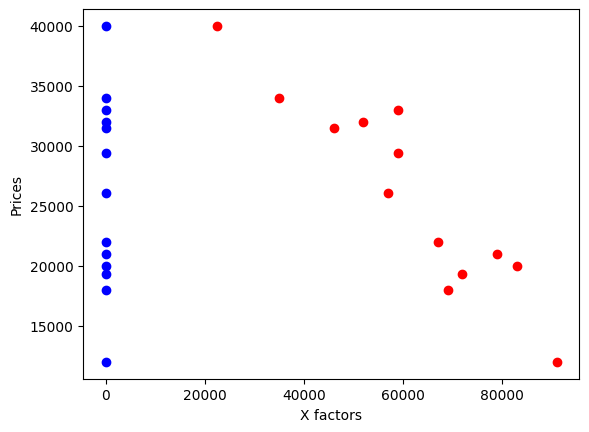

In [48]:
%matplotlib inline 
plt.scatter(df['Mileage'], df['Sell Price($)'] ,color='red')
plt.scatter(df['Age(yrs)'], df['Sell Price($)'] ,color='blue')
plt.xlabel("X factors")
plt.ylabel("Prices")

In [55]:
dc=pd.get_dummies(df['Car Model']);
dc

,Audi A5,BMW X5,Mercedez Benz C class
0,False,True,False
1,False,True,False
2,False,True,False
3,False,True,False
4,False,True,False
5,True,False,False
6,True,False,False
7,True,False,False
8,True,False,False
9,False,False,True


In [56]:
merged= pd.concat([df,dc],axis='columns')
merged

,Car Model,Mileage,Sell Price($),Age(yrs),Audi A5,BMW X5,Mercedez Benz C class
0,BMW X5,69000,18000,6,False,True,False
1,BMW X5,35000,34000,3,False,True,False
2,BMW X5,57000,26100,5,False,True,False
3,BMW X5,22500,40000,2,False,True,False
4,BMW X5,46000,31500,4,False,True,False
5,Audi A5,59000,29400,5,True,False,False
6,Audi A5,52000,32000,5,True,False,False
7,Audi A5,72000,19300,6,True,False,False
8,Audi A5,91000,12000,8,True,False,False
9,Mercedez Benz C class,67000,22000,6,False,False,True


In [57]:
final=merged.drop(["Car Model","Audi A5"],axis='columns')
final

,Mileage,Sell Price($),Age(yrs),BMW X5,Mercedez Benz C class
0,69000,18000,6,True,False
1,35000,34000,3,True,False
2,57000,26100,5,True,False
3,22500,40000,2,True,False
4,46000,31500,4,True,False
5,59000,29400,5,False,False
6,52000,32000,5,False,False
7,72000,19300,6,False,False
8,91000,12000,8,False,False
9,67000,22000,6,False,True


In [32]:
model=linear_model.LinearRegression()

In [58]:
X=final.drop(["Sell Price($)"],axis="columns").values
X

array([[69000, 6, True, False],
       [35000, 3, True, False],
       [57000, 5, True, False],
       [22500, 2, True, False],
       [46000, 4, True, False],
       [59000, 5, False, False],
       [52000, 5, False, False],
       [72000, 6, False, False],
       [91000, 8, False, False],
       [67000, 6, False, True],
       [83000, 7, False, True],
       [79000, 7, False, True],
       [59000, 5, False, True]], dtype=object)

In [59]:
y=final["Sell Price($)"]
y

0     18000
1     34000
2     26100
3     40000
4     31500
5     29400
6     32000
7     19300
8     12000
9     22000
10    20000
11    21000
12    33000
Name: Sell Price($), dtype: int64

In [60]:
model.fit(X,y)

LinearRegression()

In [61]:
model.score(X,y)

0.9417050937281082

In [62]:
model.predict([[36000,3,1,0]])

array([34916.66236206])

In [66]:
model.predict([[60000,7,False,False]])

array([24988.58417469])

In [69]:
model.predict([[45000,4,False,True]])

array([36991.31721061])

In [70]:
model.predict([[86000,7,1,0]])

array([11080.74313219])